In [1]:
"""
This is the main code to build models and solve the forecast problems.
The results are saved to feed into the real time operation models.
The inputs are PV and Load forecast scenarios + various device specifications + penalties
The output is the GUROBI model which is saved as .mps file
"""
import pickle as pkl
import warnings
warnings.filterwarnings('ignore')

#### Auto Reloading for External Libraries

In [65]:
# Using this magic command, we turn on auto-reloading for libraries imported by %aimport
%load_ext autoreload
%autoreload 1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
# Can be reloaded multiple times
%aimport solveDayAhead
%aimport solveRealTime
%aimport reporting
%aimport buildMG
%aimport buildCEMS
from solveDayAhead import solveDAMGs, solveDACEMS
from solveRealTime import solveRT
from reporting import saveDAToCSV, saveRTToCSV, plotDAvsRT

In [76]:
class mg_c:
    """ we need this class to preserve MGs information all the time."""
    def __init__(self, fixed_file, scenario_file, init_E0):
        with open(fixed_file, 'rb') as handle:
            self.gamma, self.dv, self.effic, self.alpha, self.Klimits = pkl.load(handle)
        handle.close()
        with open(scenario_file, 'rb') as handle:
            self.ps, self.pv_s, self.l_s, self.l_max = pkl.load(handle)
        handle.close()
        self.E0 = init_E0
class cems_c:
    """We need this class to preserve CEMS information all the time."""
    def __init__(self, fixed_file, scenario_file, init_E0):
        with open(fixed_file, 'rb') as handle:
            self.gamma, self.dv, self.effic, self.theta = pkl.load(handle)
        handle.close()
        with open(scenario_file, 'rb') as handle:
            self.ps, self.pv_s = pkl.load(handle)
        handle.close()
        self.E0 = init_E0

MG = 3  # Number of MGs
SH, PH, CH = 24, 4, 1  # Scheduling horizon, Prediction horizon, Control Horizon
init_E0 = {mg: 0.9 for mg in range(MG)}  # Initial EMS level of MGs
init_E0_cems = 0.9  # Initial ES level of CEMS

# Build Models for Microgrids Given Initial Parameters
folder = 'systemInfo/'
mgi = {mg: mg_c(folder+f'mg{mg}-fixed.pkl', folder+f'mg{mg}-scenario.pkl', init_E0[mg]) for mg in range(MG)}
cems = cems_c(folder+f'cems-fixed.pkl', folder+f'cems-scenario.pkl', init_E0_cems)

In [77]:
# Solve DayAhead to Optimality all MGs and CEMS
solveDAMGs(mgi, SH)
solveDACEMS(cems, mgi, SH)

# Save day ahead data in csv
saveDAToCSV(SH)

Energy Access: 63.23%, Energy Resilience: 87.82%, Energy Sustainability: 1.21%.


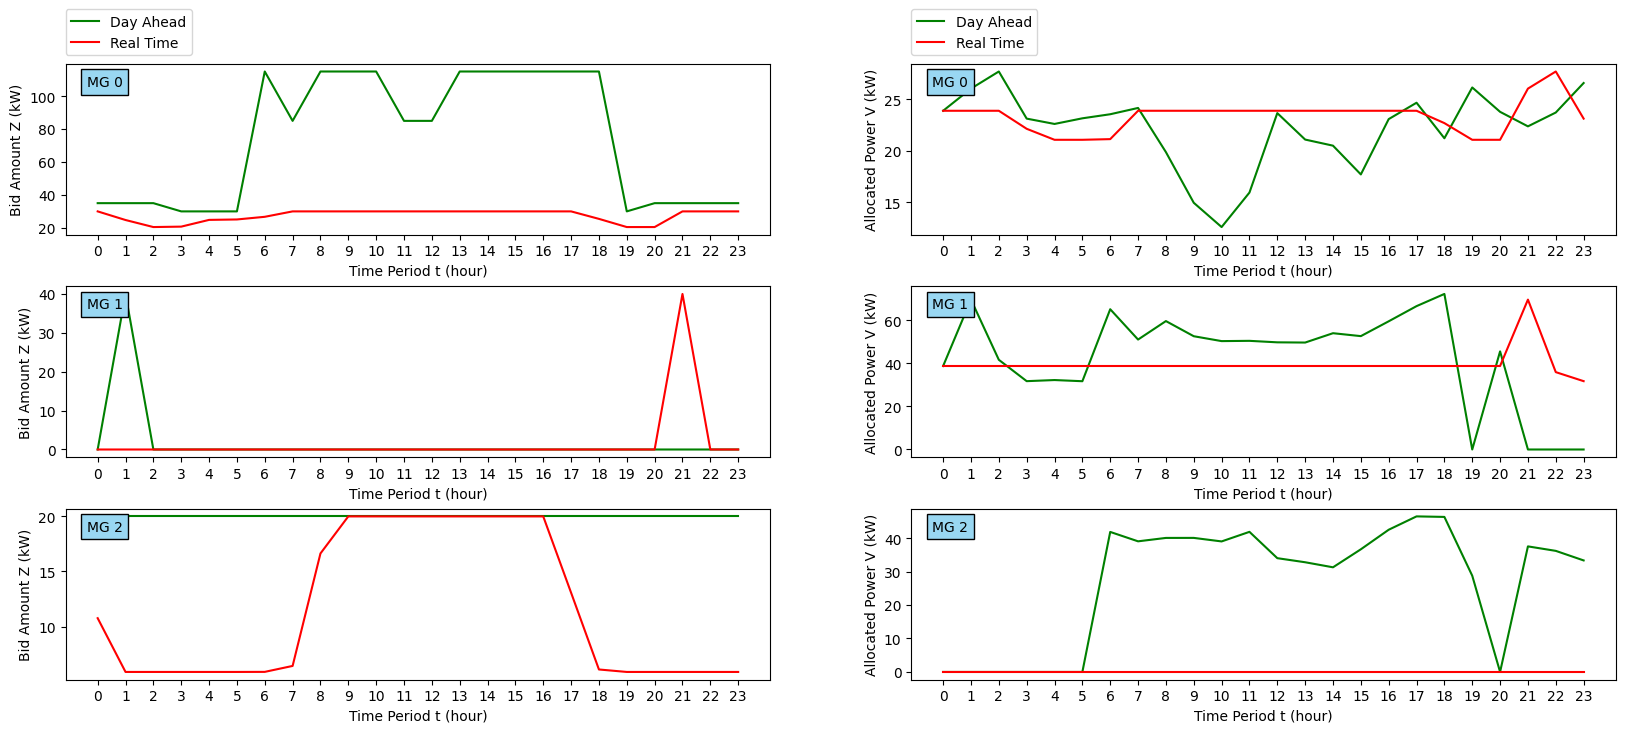

In [80]:
# Solve real time
solveRT(mgi, cems, SH, PH, CH)
saveRTToCSV(SH)
# Plot results
l = plotDAvsRT(MG)